In [ ]:
mkdir -p ~/.kaggle && echo KGAT_5a95b819c9041282afdaf69f4f5aa0c0 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d sukhmandeepsinghbrar/housing-price-dataset

Dataset URL: https://www.kaggle.com/datasets/sukhmandeepsinghbrar/housing-price-dataset
License(s): CC0-1.0
housing-price-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip housing-price-dataset.zip

Archive:  housing-price-dataset.zip
replace Housing.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Housing.csv             


In [ ]:
import pandas as pd

df = pd.read_csv("Housing.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,306,147.71","540,088.58",3.37,2.11,"2,079.90","15,106.97",1.49,0.01,0.23,3.41,7.66,"1,788.39",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
std,"2,876,569,751.89","367,126.83",0.93,0.77,918.44,"41,420.51",0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"
min,"1,000,102.00","75,000.00",0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00","321,950.00",3.00,1.75,"1,427.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00","450,000.00",3.00,2.25,"1,910.00","7,618.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00","645,000.00",4.00,2.50,"2,550.00","10,688.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00","7,700,000.00",33.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"


In [ ]:
print("----Description----")
print( "Number of Observations =",df.shape[0],end ="\n")
print("Number of Features =" ,df.shape[1],end='\n\n')
print('Data Types',df.dtypes,end='\n\n')
print('Missing Values',df.isnull().sum(),end='\n')
print('Duplicate Records',df.duplicated().sum(),end='\n')

----Description----
Number of Observations = 21613
Number of Features = 21

Data Types id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Missing Values id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long            

In [ ]:
import plotly.express as px
fig = px.histogram(df, x= df['price'],nbins=10, title='Distribution of House Prices',
    labels={'price': 'House Price', 'count': 'Number of Houses'})
fig.update_layout(bargap=0.2)
fig.show()

In [ ]:
fig = px.scatter(df, x="bedrooms", y="bathrooms",color='price')
fig.show()

In [ ]:

df["zipcode"] = df["zipcode"].astype(str)
fig = px.scatter(df, y="price", x="zipcode")
fig.show()


In [ ]:

df["view"] = df["view"].astype(str)
fig = px.scatter(df, y="price", x="view")
fig.show()

In [ ]:
fig = px.scatter(df, x="sqft_living", y="price")
fig.show()

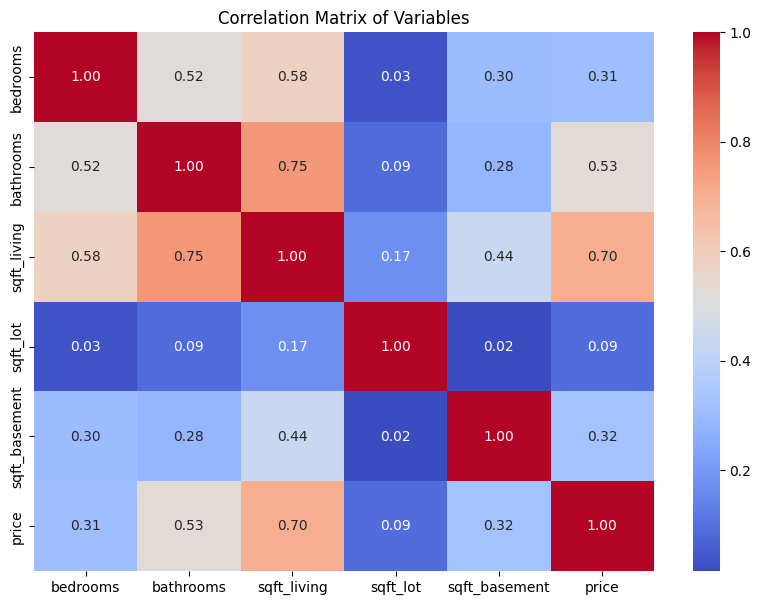

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
columns = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "sqft_basement",
    'price'

]
correlation_matrix = df[columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Variables")
plt.show()

In [ ]:
numeric_cols = ['price','bedrooms','bathrooms','sqft_living']


outlier_mask = pd.Series(False, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask |= (df[col] < lower_bound) | (df[col] > upper_bound)

print("Number of outlier rows:", outlier_mask.sum())

df_clean = df[~outlier_mask]

print("Original shape:", df.shape)
print("New shape:", df_clean.shape)

Number of outlier rows: 1940
Original shape: (21613, 21)
New shape: (19673, 21)


In [ ]:
fig = px.histogram(df_clean, x= df_clean['price'],nbins=30, title='Distribution of House Prices',
    labels={'price': 'House Price', 'count': 'Number of Houses'})
fig.update_layout(bargap=0.2)
fig.show()

In [ ]:
fig = px.box(
    df_clean,
    y='price',
    title='Box Plot of House Prices'
)

fig.show()

In [ ]:
fig = px.scatter(df_clean, x="bedrooms", y="bathrooms",color='price')
fig.show()

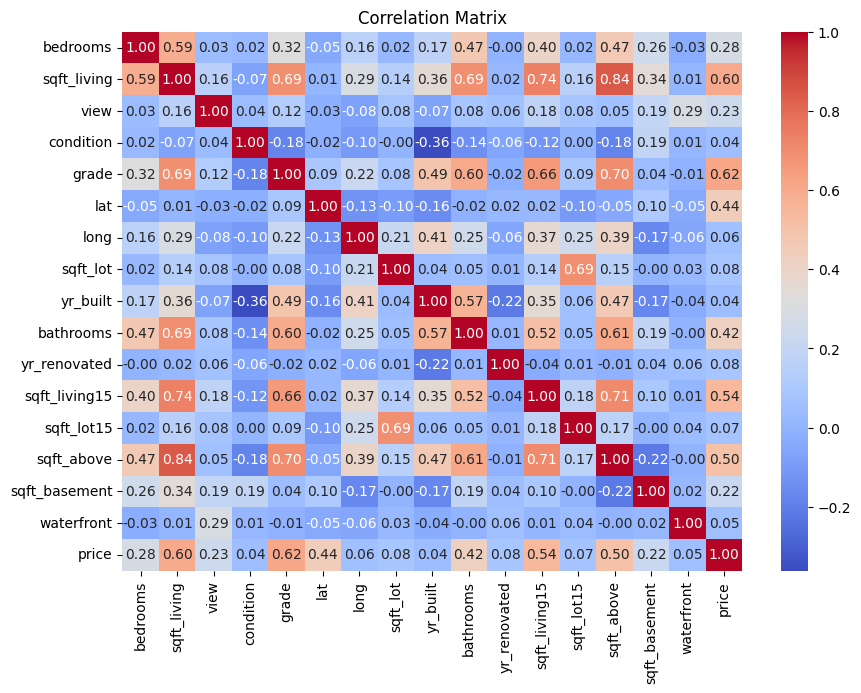

In [ ]:
columns = [
    "bedrooms",
    "sqft_living",
    "view",
    "condition",
    'grade','lat','long', 'sqft_lot','yr_built','bathrooms','yr_renovated','sqft_living15','sqft_lot15','sqft_above','sqft_basement','waterfront',
    'price'

]
correlation_matrix = df_clean[columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
target = df_clean['price']
df_clean = df_clean.drop(columns=['price', 'id','long', 'sqft_lot','yr_built','yr_renovated','sqft_lot15','date','sqft_basement','waterfront',"condition"])
print(df_clean.shape)

(19673, 10)


In [ ]:
df_clean.head(5)

,bedrooms,bathrooms,sqft_living,floors,view,grade,sqft_above,zipcode,lat,sqft_living15
0,2,1.00,1180,1.00,0,7,1180,98178,47.51,1340
1,3,2.25,2570,2.00,0,7,2170,98125,47.72,1690
2,2,1.00,770,1.00,0,6,770,98028,47.74,2720
3,4,3.00,1960,1.00,0,7,1050,98136,47.52,1360
4,3,2.00,1680,1.00,0,8,1680,98074,47.62,1800


In [ ]:
import numpy as np
# 80-20 train-test split
np.random.seed(42)
indices = np.random.permutation(len(df_clean))
split = int(0.8 * len(df_clean))
train_idx = indices[:split]
test_idx = indices[split:]
X_train = df_clean.iloc[train_idx]
X_test = df_clean.iloc[test_idx]
y_train = target.iloc[train_idx]
y_test = target.iloc[test_idx]

# Calculate mean and standard deviation ONLY from training data


In [ ]:
print(X_train.head(2))

       bedrooms  bathrooms  sqft_living  floors  view  grade  sqft_above  \
9320          3       1.75         1830    1.00     1      7        1200   
15250         3       1.50         1120    1.00     0      7        1120   

       zipcode   lat  sqft_living15  
9320     98178 47.51           1830  
15250    98007 47.60           1300  


In [ ]:
X_train = pd.get_dummies(X_train, columns=['zipcode', 'view',"grade","floors","bathrooms","bedrooms"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['zipcode', 'view',"grade","floors","bathrooms","bedrooms"], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print(X_train.head(2))

       sqft_living  sqft_above   lat  sqft_living15  zipcode_98002  \
9320          1830        1200 47.51           1830          False   
15250         1120        1120 47.60           1300          False   

       zipcode_98003  zipcode_98004  zipcode_98005  zipcode_98006  \
9320           False          False          False          False   
15250          False          False          False          False   

       zipcode_98007  ...  bathrooms_2.0  bathrooms_2.25  bathrooms_2.5  \
9320           False  ...          False           False          False   
15250           True  ...          False           False          False   

       bathrooms_2.75  bathrooms_3.0  bathrooms_3.25  bathrooms_3.5  \
9320            False          False           False          False   
15250           False          False           False          False   

       bedrooms_3  bedrooms_4  bedrooms_5  
9320         True       False       False  
15250        True       False       False  

[2 rows 

In [ ]:
train_mean = X_train.mean()
train_std = X_train.std()
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std
print(X_train_scaled.head())

       sqft_living  sqft_above   lat  sqft_living15  zipcode_98002  \
9320         -0.15       -0.70 -0.34          -0.13          -0.10   
15250        -1.15       -0.82  0.32          -1.02          -0.10   
14218        -0.76       -0.41  1.51          -0.70          -0.10   
2834          0.17       -0.32  0.26           0.26          -0.10   
8663         -0.18        0.19  1.24          -0.75          -0.10   

       zipcode_98003  zipcode_98004  zipcode_98005  zipcode_98006  \
9320           -0.11          -0.09          -0.09          -0.14   
15250          -0.11          -0.09          -0.09          -0.14   
14218          -0.11          -0.09          -0.09          -0.14   
2834           -0.11          -0.09          11.60          -0.14   
8663           -0.11          -0.09          -0.09          -0.14   

       zipcode_98007  ...  bathrooms_2.0  bathrooms_2.25  bathrooms_2.5  \
9320           -0.08  ...          -0.33           -0.33          -0.59   
15250         

In [ ]:
import numpy as np
X_train_np = X_train_scaled.to_numpy()
y_train_np = y_train.to_numpy()

# Add a column of 1s for the intercept
X_train_bias = np.c_[np.ones(X_train_np.shape[0]), X_train_np]


In [ ]:
print(X_train_bias)

[[ 1.         -0.41098786 -0.06656684 ... -0.97590851  1.48409345
  -0.25005169]
 [ 1.         -1.38300473 -1.05257875 ... -0.97590851 -0.67376872
  -0.25005169]
 [ 1.         -1.3115329  -0.98007787 ...  1.02462039 -0.67376872
  -0.25005169]
 ...
 [ 1.         -0.8541132  -0.51607227 ...  1.02462039 -0.67376872
  -0.25005169]
 [ 1.         -0.58252025 -0.24056894 ... -0.97590851  1.48409345
  -0.25005169]
 [ 1.          0.17508114  0.52794034 ...  1.02462039 -0.67376872
  -0.25005169]]


In [ ]:
theta = np.linalg.pinv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train_np

print("Learned Parameters (Theta):")
for i, value in enumerate(theta):
  print(f"Theta_{i} = {value}",X_train.columns[i-1])



Learned Parameters (Theta):
Theta_0 = 470190.869450691 bedrooms_5
Theta_1 = 58187.00069863838 sqft_living
Theta_2 = 25829.877565484567 sqft_above
Theta_3 = 16777.77669392128 lat
Theta_4 = 16088.23687667517 sqft_living15
Theta_5 = 1482.2283026562116 zipcode_98002
Theta_6 = -381.0084009916834 zipcode_98003
Theta_7 = 41155.15094344479 zipcode_98004
Theta_8 = 25517.342133168942 zipcode_98005
Theta_9 = 33073.50245031774 zipcode_98006
Theta_10 = 18562.047116072503 zipcode_98007
Theta_11 = 23929.631238109592 zipcode_98008
Theta_12 = 6303.729317906609 zipcode_98010
Theta_13 = 8476.3201256099 zipcode_98011
Theta_14 = 4767.348459946136 zipcode_98014
Theta_15 = 4792.767743680847 zipcode_98019
Theta_16 = 4220.743397722827 zipcode_98022
Theta_17 = -3245.4854272456973 zipcode_98023
Theta_18 = 8270.67979337971 zipcode_98024
Theta_19 = 23795.2219643319 zipcode_98027
Theta_20 = 9590.772225331853 zipcode_98028
Theta_21 = 23780.126800642887 zipcode_98029
Theta_22 = -101.43699411961347 zipcode_98030
Theta


Learning Rate: 0.001
Parameters:
Theta_0 = 298174.67460283136
Theta_1 = 31996.678772103336
Theta_2 = 20068.692243969566
Theta_3 = 38329.22782400824
Theta_4 = 25046.374178948143
Theta_5 = -7617.6415445717075
Theta_6 = -8536.77306115876
Theta_7 = 18548.127428896376
Theta_8 = 10155.198130629391
Theta_9 = 11761.951622465049
Theta_10 = 4460.2658396555
Theta_11 = 5613.105143069364
Theta_12 = -1020.8321292614665
Theta_13 = -3790.768987365257
Theta_14 = -3276.4772205578274
Theta_15 = -6763.727305166245
Theta_16 = -4916.919022000159
Theta_17 = -14039.161467371492
Theta_18 = -273.27573139400835
Theta_19 = 3290.231769741633
Theta_20 = -5442.723281995412
Theta_21 = 3660.825795896399
Theta_22 = -9505.339052953015
Theta_23 = -9365.918902348147
Theta_24 = -6916.313898199298
Theta_25 = 12236.097034627832
Theta_26 = -1749.2327107547035
Theta_27 = -10588.969372655505
Theta_28 = 5237.751208614736
Theta_29 = 15550.24739642534
Theta_30 = -12396.001600406844
Theta_31 = -2639.8990375333005
Theta_32 = 7517.7

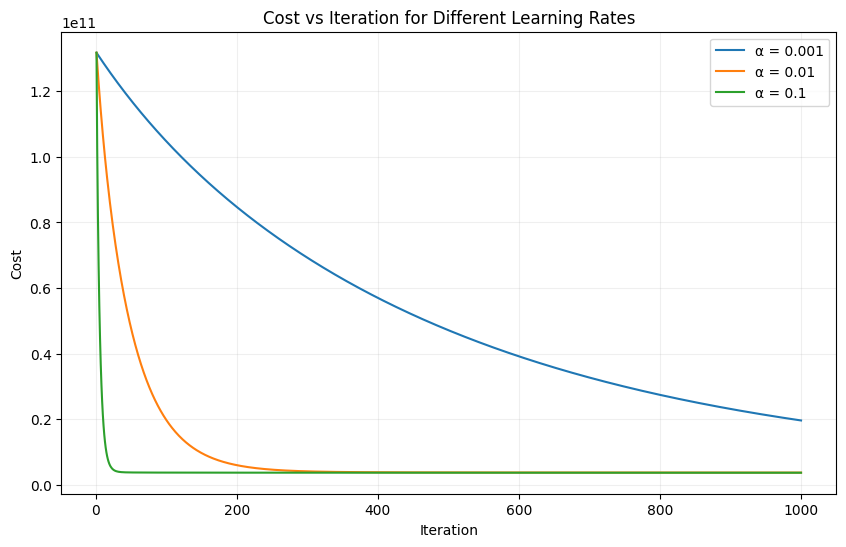

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
X = X_train_scaled.to_numpy()
y = y_train.to_numpy()
X = np.c_[np.ones(X.shape[0]), X]

# Gradient Descent function
def gradient_descent(X, y, alpha, iterations):
    m = len(y)
    # Initialize parameters to zero
    theta = np.zeros(X.shape[1])
    cost_history = []
    for i in range(iterations):
        # Predictions
        predictions = X @ theta
        # Errors
        errors = predictions - y
        # Gradient
        gradient = (1 / m) * (X.T @ errors)
        # Update parameters
        theta = theta - alpha * gradient
        # Cost
        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history.append(cost)
    return theta, cost_history


# Learning rates
learning_rates = [0.001, 0.01, 0.1]
iterations = 1000
results = {}
# Run Gradient Descent for each learning rate
for alpha in learning_rates:
    theta_gd, cost_history = gradient_descent(
        X, y, alpha, iterations
    )
    results[alpha] = {
        "theta": theta_gd,
        "cost": cost_history
    }
    print(f"\nLearning Rate: {alpha}")
    print("Parameters:")
    for i, value in enumerate(theta_gd):
        print(f"Theta_{i} = {value}")

# Plot cost vs iterations
plt.figure(figsize=(10, 6))
for alpha in learning_rates:
    plt.plot(
        range(1, iterations + 1),
        results[alpha]["cost"],
        label=f"α = {alpha}"
    )
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration for Different Learning Rates")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
X_test_np = X_test_scaled.to_numpy()
y_test_np = y_test.to_numpy()

X_test_bias = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

# Use the final Gradient Descent parameters (alpha = 0.1)
theta_final = results[0.1]["theta"]
y_pred = X_test_bias @ theta_final
errors = y_test_np - y_pred
# MAE
MAE = np.mean(np.abs(errors))
# MSE
MSE = np.mean(errors ** 2)
# RMSE
RMSE = np.sqrt(MSE)
# R²
SS_res = np.sum(errors ** 2)
SS_tot = np.sum((y_test_np - np.mean(y_test_np)) ** 2)
R2 = 1 - (SS_res / SS_tot)
print("Model Evaluation on Test Data")
print("--------------------------------")
print(f"MAE  : {MAE:.2f}")
print(f"MSE  : {MSE:.2f}")
print(f"RMSE : {RMSE:.2f}")
print(f"R²   : {R2:.4f}")

Model Evaluation on Test Data
--------------------------------
MAE  : 61341.49
MSE  : 7052068949.31
RMSE : 83976.60
R²   : 0.8278


In [ ]:
error_percentage = (RMSE / y_test.mean()) * 100
print(f"Average Error: {error_percentage:.2f}%")


Average Error: 17.82%
